# BioSample trace-back analysis

This notebook explains how extracted BioSample field values are traced back to their source records -- the matching cascade's tiers, what each one means, and how well it performs across the crate's 9 target fields -- then examines how those curated fields are represented in the original raw metadata: how many raw field names contribute evidence to each one, how concentrated that evidence is, how much comes from structured fields versus free text, and how these patterns vary across the dataset and over time. It does not evaluate individual matching errors or the LLM evidence tier's precision/recall against a reviewed ground truth; that's in `biosample_trace_back_evaluation.ipynb`.

In [1]:
# TABLE OF CONTENTS
import sys

sys.path.insert(0, "../src")
from notebook_utils import table_of_contents

table_of_contents("biosample_trace_back_analysis.ipynb")

### Table of contents

- [Setup](#Setup)
- [Raw-field diversity](#Raw-field-diversity)
  - [Evidence concentration](#Evidence-concentration)
- [How does raw-field-name diversity vary by year?](#How-does-raw-field-name-diversity-vary-by-year?)

## Setup

In [2]:
# IMPORTS
import html
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bs_entries import MATCH_STRATEGIES
from field_diversity import (
    concentration_curve,
    explode_raw_fields,
    is_free_text_field,
    normalize_field_name,
    rarefied_unique_counts,
)
from notebook_utils import RawHTML, display_with_nested_tables, md
from paths import (
    BIOSAMPLE_METADATA_PARQUET,
    LLM_EVIDENCE_QWEN3_8B_JSONLS,
    LLM_EVIDENCE_QWEN3_32B_JSONLS,
    TRACE_BACK_FULL_PARQUET,
)

/workspace/BH26/BH26_BioSample_curation/.conda_env/lib/python3.12/site-packages/torch/cuda/__init__.py:228: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
# LOAD AND JOIN: trace-back rows, per-accession metadata, exploded to one row per evidence field
trace_back = pd.read_parquet(TRACE_BACK_FULL_PARQUET)

metadata = pd.read_parquet(BIOSAMPLE_METADATA_PARQUET).drop_duplicates("accession")
metadata["year_submission"] = pd.to_datetime(metadata["submission_date"], format="mixed", utc=True, errors="coerce").dt.year
metadata["year_publication"] = pd.to_datetime(metadata["publication_date"], format="mixed", utc=True, errors="coerce").dt.year

exploded = explode_raw_fields(trace_back).merge(
    metadata[["accession", "bioproject_id", "owner", "year_submission", "year_publication"]], on="accession", how="left"
)
exploded["raw_field_norm"] = exploded["raw_field"].map(normalize_field_name)
exploded["is_free_text"] = exploded["raw_field"].map(is_free_text_field)

STRATEGY_ORDER = [*MATCH_STRATEGIES, "not found"]
TARGET_FIELDS = sorted(trace_back["target_field"].unique())

md(f"Loaded **{len(trace_back):,}** trace-back rows across **{trace_back['accession'].nunique():,}** accessions, **{trace_back['run_name'].nunique()}** runs; **{len(exploded):,}** (value, evidence field) pairs after exploding the found ones.")

Loaded **8,194,813** trace-back rows across **3,989,387** accessions, **311** runs; **8,618,975** (value, evidence field) pairs after exploding the found ones.

In [4]:
# FIXED CATEGORICAL PALETTE FOR THE 9 TARGET FIELDS (Okabe-Ito, colorblind-safe, fixed order)
TARGET_FIELD_COLORS = dict(
    zip(TARGET_FIELDS, ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#999999", "#000000"])
)

In [5]:
# YEAR RANGE AND RAREFACTION SETTINGS, SHARED BY EVERY YEAR-TREND ANALYSIS BELOW
YEAR_RANGE = (2012, 2025)  # earlier years too sparse for a stable rarefied estimate; 2026 only partially elapsed
N_RAREFACTION_ITER = 10

## How extracted values were traced back to the source record

Each extracted value is tested against its own source record through a fixed cascade, from strictest to most tolerant, moving to the next tier only when the current one fails to find it; for values every deterministic tier fails on, two LLM passes (a smaller model, then a larger one over whatever the smaller model still couldn't ground) get a turn before a value is finally left `not found`.

In [6]:
# LLM EVIDENCE TIER TALLIES: PER-TARGET-FIELD "llm"/"not found" COUNTS, ONE PER MODEL SIZE
def llm_pass_tallies(paths: list[Path]) -> pd.DataFrame:
    """Per-target-field counts of the LLM evidence tier's own verdict ("llm" if a proposed quote
    grounded, else "not found"), read directly from a pass's `--out` jsonl files. These carry the
    tier's OWN accounting of the residual it processed, which `trace_back` doesn't -- it only has
    the deterministic cascade's verdict, which is "not found" for every item an LLM pass sees.
    """
    counts: dict[str, dict[str, int]] = {}
    for path in paths:
        with path.open() as f:
            for line in f:
                record = json.loads(line)
                for row in record["rows"]:
                    field_counts = counts.setdefault(row["target_field"], {})
                    field_counts[row["strategy"]] = field_counts.get(row["strategy"], 0) + 1
    return pd.DataFrame(counts).T.fillna(0).astype(int).rename_axis("target_field")


qwen3_8b_tally = llm_pass_tallies(LLM_EVIDENCE_QWEN3_8B_JSONLS)
qwen3_32b_tally = llm_pass_tallies(LLM_EVIDENCE_QWEN3_32B_JSONLS)

LLM_TIERS = ["Qwen3-8B", "Qwen3-32B"]
STRATEGY_ORDER = [*MATCH_STRATEGIES, *LLM_TIERS, "not found"]


# COUNTS PER (TARGET FIELD, STRATEGY), DETERMINISTIC TIERS PLUS THE TWO LLM PASSES
def strategy_breakdown(trace_back: pd.DataFrame, qwen3_8b_tally: pd.DataFrame, qwen3_32b_tally: pd.DataFrame) -> pd.DataFrame:
    counts = trace_back.groupby(["target_field", "strategy"]).size().unstack(fill_value=0)
    counts.columns.name = None
    counts = counts.reindex(columns=MATCH_STRATEGIES, fill_value=0)
    # the LLM tiers' own tallies replace the deterministic cascade's "not found" column outright:
    # every item ever "not found" deterministically is accounted for by exactly one of the three
    # columns below (Qwen3-8B grounded it, Qwen3-32B grounded what Qwen3-8B couldn't, or neither
    # did), so nothing here double-counts or needs the deterministic "not found" column at all.
    counts["Qwen3-8B"] = qwen3_8b_tally["llm"].reindex(counts.index, fill_value=0)
    counts["Qwen3-32B"] = qwen3_32b_tally["llm"].reindex(counts.index, fill_value=0)
    counts["not found"] = qwen3_32b_tally["not found"].reindex(counts.index, fill_value=0)
    counts["n_with_value"] = counts[STRATEGY_ORDER].sum(axis=1)
    counts["pct_found"] = 100 * (counts["n_with_value"] - counts["not found"]) / counts["n_with_value"]
    return counts.reset_index()


strategy_stats = strategy_breakdown(trace_back, qwen3_8b_tally, qwen3_32b_tally)
strategy_stats.style.format({**{col: "{:,}" for col in [*STRATEGY_ORDER, "n_with_value"]}, "pct_found": "{:.1f}"})

,target_field,exact,case-insensitive,normalized,ontology synonym,bag of words,fuzzy,Qwen3-8B,Qwen3-32B,not found,n_with_value,pct_found
0,cell_line,"964,387","6,148","9,302","1,695",22,561,"1,244",204,"1,844","985,407",99.8
1,cell_type,"1,481,228","35,046","270,909","14,053",460,"4,330","43,088","16,402","25,220","1,890,736",98.7
2,chip_antigen,"347,358","4,166","1,396","1,184",3,139,"1,893","1,172","3,438","360,749",99.0
3,disease,"533,108","46,927","2,396","19,823",105,"1,049","20,393","4,181","7,269","635,251",98.9
4,drug,"745,717","14,430","3,430","7,517",209,525,"13,429","4,124","2,396","791,777",99.7
5,knockdown_gene,"53,761","1,642","20,143",642,2,26,"5,610","2,146","1,598","85,570",98.1
6,knockout_gene,"327,959","8,511","55,451","11,333",0,174,"23,144","3,766","14,495","444,833",96.7
7,overexpressed_gene,"164,884","4,876","20,262","1,696",56,48,"7,856","2,799","4,116","206,593",98.0
8,tissue,"2,460,412","199,081","19,402","18,166",44,"4,780","53,937","20,387","19,321","2,795,530",99.3


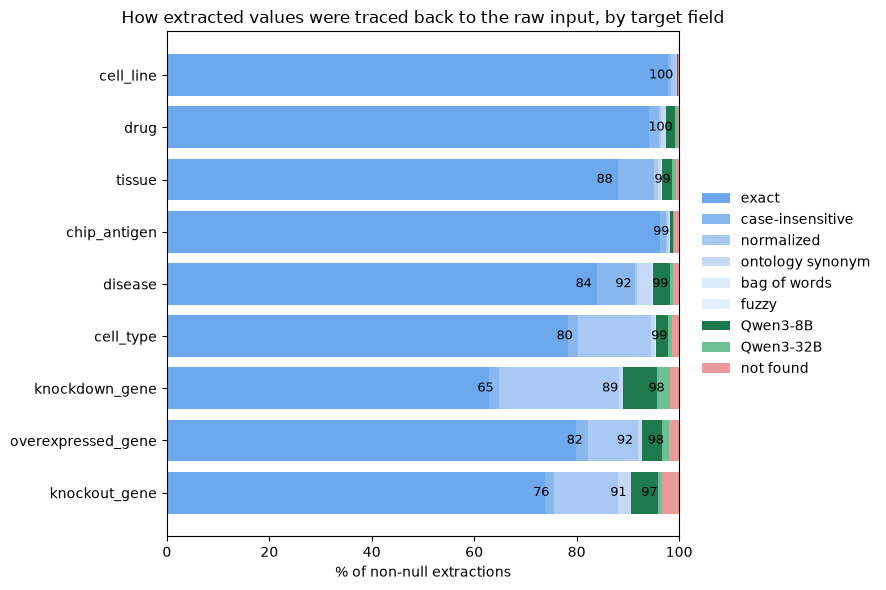

In [7]:
# STACKED PLOT: % OF EXTRACTIONS FOUND PER TIER, PER TARGET FIELD
def _select_label_positions(candidates: list[float], min_gap: float = 6.0) -> list[float]:
    """From candidate label positions (cumulative % boundaries on one bar), picks which to
    actually render as text: always the largest, then each next-largest only if it's at
    least `min_gap` percentage points from the last one kept -- otherwise two close
    boundaries produce overlapping, unreadable text (e.g. 58% and 59% back to back).
    """
    ordered = sorted(set(candidates), reverse=True)
    kept: list[float] = []
    for value in ordered:
        if not kept or (kept[-1] - value) >= min_gap:
            kept.append(value)
    return kept


def plot_strategy_breakdown(stats: pd.DataFrame, figsize: tuple[float, float] = (9, 6)) -> None:
    order = STRATEGY_ORDER
    # a blue gradient for the deterministic tiers (strongest darkest, sized to however many
    # MATCH_STRATEGIES currently has -- built from live STRATEGY_ORDER, not a hardcoded dict,
    # since this pipeline's tiers have changed before and a hardcoded dict silently KeyErrors the
    # moment a new one shows up in the data), two greens for the two LLM passes (Qwen3-8B first,
    # the larger Qwen3-32B second over whatever Qwen3-8B still couldn't ground), and red for
    # whatever neither deterministic matching nor either LLM pass could find.
    blues = ["#6da7ec", "#89b8ef", "#a8c9f4", "#c6daf8", "#daeaf9", "#e3eefc"]
    colors = dict(zip(MATCH_STRATEGIES, blues[: len(MATCH_STRATEGIES)])) | {
        "Qwen3-8B": "#1e7a4d",
        "Qwen3-32B": "#6dbf94",
        "not found": "#eb9a9a",
    }

    fields = stats.sort_values("pct_found")["target_field"].tolist()
    pct = stats.set_index("target_field")
    pct = pct[order].div(pct["n_with_value"], axis=0) * 100
    pct = pct.loc[fields]

    fig, ax = plt.subplots(figsize=figsize)
    y_pos = list(range(len(fields)))
    left = pd.Series(0.0, index=pct.index)
    for strategy in order:
        ax.barh(y_pos, pct[strategy], left=left, label=strategy, color=colors[strategy])
        left += pct[strategy]

    for y, field in zip(y_pos, fields):
        # candidate label positions are cumulative boundaries over every FOUND tier (deterministic
        # and LLM alike, never "not found" itself) -- the largest candidate is always the overall
        # pct_found after both LLM passes, guaranteeing it's shown even when the last slice is thin
        cum = 0.0
        candidates = []
        for strategy in [*MATCH_STRATEGIES, *LLM_TIERS]:
            cum += pct.loc[field, strategy]
            if pct.loc[field, strategy] > 0:
                candidates.append(cum)
        for value in _select_label_positions(candidates):
            ax.text(value - 1, y, f"{value:.0f}", va="center", ha="right", fontsize=9, color="black")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fields)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of non-null extractions")
    ax.set_title("How extracted values were traced back to the raw input, by target field")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()


plot_strategy_breakdown(strategy_stats)

In [8]:
# POOLED COUNT AND PERCENTAGE PER TIER, ACROSS ALL 9 TARGET FIELDS -- WHAT THE PLOT ABOVE AVERAGES OVER
pooled_tier_totals = strategy_stats[STRATEGY_ORDER].sum()
pooled_total = pooled_tier_totals.sum()

md(
    f"Across all **{pooled_total:,}** extracted field values checked: "
    + ", ".join(f"**{n:,} ({100 * n / pooled_total:.1f}%)** {tier}" for tier, n in pooled_tier_totals.items())
    + "."
)

Across all **8,196,446** extracted field values checked: **7,078,814 (86.4%)** exact, **320,827 (3.9%)** case-insensitive, **402,691 (4.9%)** normalized, **76,109 (0.9%)** ontology synonym, **901 (0.0%)** bag of words, **11,632 (0.1%)** fuzzy, **170,594 (2.1%)** Qwen3-8B, **55,181 (0.7%)** Qwen3-32B, **79,697 (1.0%)** not found.

### What each tier means

A value stops at the first tier that finds it and only falls through to the next when that tier fails, so the tiers below run in this exact order:

- **exact**: the extracted value appears verbatim, character-for-character, somewhere in the record's own text.
- **case-insensitive**: the value appears verbatim except for letter case (e.g. `"Lung"` vs. `"lung"`).
- **normalized**: matches after stripping parenthetical asides and collapsing separators (spaces, underscores, hyphens) -- catches formatting variants like `"cell-type"` vs. `"cell_type"`.
- **ontology synonym**: matches one of the registered synonyms for the ontology term the value was mapped to, rather than the value's own literal text -- itself tried with bag-of-words and fuzzy tolerance, same as the two tiers below.
- **bag of words**: every word in the value (or a matched synonym) appears somewhere in the record, in any order -- catches reworded phrases and attribute values with their words rearranged.
- **fuzzy**: a spelling-tolerant word match, reserved for words of 6+ characters, that also resolves fused gene/construct names, bracketed phrases, and visually similar characters.
- **Qwen3-8B**: for values no deterministic tier could place, this open-weight LLM is given the record's own raw text and asked for a direct statement or a specific, well-supported inference -- never outside domain knowledge -- and every quote it proposes is independently re-checked against the source text with the same substring search the deterministic tiers use, before being trusted.
- **Qwen3-32B**: a second, larger-model pass over whatever Qwen3-8B still couldn't ground, run under the identical prompt and grounding check.
- **not found**: no tier -- deterministic or LLM -- found any supporting text for the value anywhere in the record.

## Raw-field diversity

The analysis below compares the number of distinct raw field names with the number remaining after simple normalization. It then shows which fields carry most of the evidence and how much of the evidence is concentrated in a small set of names.

In [9]:
# UNIQUE RAW FIELD NAMES PER TARGET FIELD, RAW VS. REGEX-NORMALIZED
def field_diversity_table(exploded: pd.DataFrame) -> pd.DataFrame:
    table = pd.DataFrame(
        {
            "n_unique_raw_field": exploded.groupby("target_field")["raw_field"].nunique(),
            "n_unique_normalized": exploded.groupby("target_field")["raw_field_norm"].nunique(),
        }
    )
    table["pct_reduction"] = 100 * (1 - table["n_unique_normalized"] / table["n_unique_raw_field"])
    return table.sort_values("n_unique_raw_field", ascending=False)


diversity_table = field_diversity_table(exploded)
diversity_table.style.format({"n_unique_raw_field": "{:,}", "n_unique_normalized": "{:,}", "pct_reduction": "{:.1f}%"})

,n_unique_raw_field,n_unique_normalized,pct_reduction
target_field,,,
overexpressed_gene,"1,717","1,648",4.0%
knockout_gene,"1,658","1,577",4.9%
cell_line,"1,477","1,369",7.3%
drug,"1,465","1,369",6.6%
chip_antigen,"1,356","1,277",5.8%
knockdown_gene,"1,183","1,133",4.2%
tissue,"1,050",962,8.4%
disease,947,877,7.4%
cell_type,843,760,9.8%


In [10]:
# POOLED ACROSS ALL 9 TARGET FIELDS
n_pooled_raw = exploded["raw_field"].nunique()
n_pooled_norm = exploded["raw_field_norm"].nunique()
md(
    f"Pooled across all target fields, there are **{n_pooled_raw:,}** distinct raw field name strings, "
    f"reduced to **{n_pooled_norm:,}** ({100 * (1 - n_pooled_norm / n_pooled_raw):.1f}% fewer) after normalization -- "
    "a real but modest reduction: most of the diversity is genuinely different field names, not just spelling/case/separator variants of the same one."
)

Pooled across all target fields, there are **6,113** distinct raw field name strings, reduced to **5,624** (8.0% fewer) after normalization -- a real but modest reduction: most of the diversity is genuinely different field names, not just spelling/case/separator variants of the same one.

### Evidence concentration

These views show which raw field names contribute most of the evidence for each curated field, and how many names are needed to cover most of it.

In [11]:
# TOP RAW FIELDS PER TARGET FIELD, BY % SHARE OF THAT FIELD'S MATCHED EVIDENCE
def top_raw_fields_per_target(exploded: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    rows = []
    for target_field in TARGET_FIELDS:
        counts = exploded.loc[exploded["target_field"] == target_field, "raw_field"].value_counts()
        total_n = counts.sum()
        top = counts.head(top_n)
        parts = [f"<b>{html.escape(field)}</b> ({100 * n / total_n:.0f}%)" for field, n in top.items()]
        n_other_fields = len(counts) - len(top)
        if n_other_fields > 0:
            parts.append(f"<b>other</b> ({n_other_fields:,} fields, {100 * (total_n - top.sum()) / total_n:.0f}%)")
        rows.append({"target_field": target_field, "total_n": total_n, "top_raw_fields": RawHTML(", ".join(parts))})
    return pd.DataFrame(rows).sort_values("total_n", ascending=False)


top_fields = top_raw_fields_per_target(exploded)
display_with_nested_tables(top_fields.assign(total_n=top_fields["total_n"].map("{:,}".format)))

target_field,total_n,top_raw_fields
tissue,"2,951,013","tissue (58%), source_name (13%), organism part (7%), body site (7%), cell type (3%), histological type (1%), biospecimen repository sample id (1%), submitted sample id (1%), disease (1%), isolate (1%), cell_type (0%), sample type (0%), study name (0%), comment (0%), tissue type (0%), title (0%), brain region (0%), cell line (0%), organ (0%), tissue_type (0%), other (1,030 fields, 5%)"
cell_type,"1,893,717","cell type (68%), source_name (7%), cell_type (7%), tissue (4%), histological type (2%), celltype (1%), cell line (1%), title (1%), inferred cell type (1%), comment (1%), cell cluster (0%), tissue/cell type (0%), isolate (0%), cell (0%), tissue/celltype (0%), ArrayExpress-CellType (0%), inferred_cell_type (0%), treatment (0%), developmental stage (0%), ArrayExpress-CELL_TYPE (0%), other (823 fields, 5%)"
cell_line,"1,067,650","cell line (52%), cell_line (23%), source_name (5%), cell type (4%), tissue (2%), isolate (2%), title (1%), biomaterial_provider (1%), Submitter Id (1%), treatment (1%), growth condition (1%), cell_type (1%), strain (1%), comment (0%), histological type (0%), cell (0%), genotype (0%), body site (0%), stimulus (0%), Ids.Id (0%), other (1,457 fields, 4%)"
drug,"922,885","treatment (54%), comment (13%), chemical_name (12%), title (2%), agent (1%), Compound (1%), sample_name (1%), stimulus (1%), chemical name (1%), study name (1%), Submitter Id (1%), source_name (1%), isolate (1%), drug treatment (0%), chemical (0%), drug (0%), treatments (0%), condition (0%), group (0%), stimulation (0%), other (1,445 fields, 9%)"
disease,"658,006","disease (24%), disease state (9%), study disease (9%), source_name (8%), tissue (7%), study name (7%), cell type (7%), diagnosis (3%), isolate (1%), histological type (1%), diseaseseverity (1%), title (1%), condition (1%), cell line (1%), health state (1%), patient diagnosis (1%), diabetes (1%), subject status (1%), treatment (1%), health_state (1%), other (927 fields, 15%)"
knockout_gene,"439,305","genotype (51%), comment (7%), title (6%), strain (6%), genotype/variation (5%), treatment (3%), source_name (2%), cell line (1%), Submitter Id (1%), cell type (1%), Ids.Id (1%), isolate (1%), sample_name (0%), group (0%), phenotype (0%), full_genotype (0%), sample description (0%), condition (0%), sample (0%), RefGroup (0%), other (1,638 fields, 11%)"
chip_antigen,"375,619","comment (35%), chip antibody (23%), antibody (9%), title (6%), phenotype (5%), facs marker (3%), immunophenotype (2%), genotype (1%), treatment (1%), cell type (1%), source_name (1%), Submitter Id (1%), target (1%), chip-antibody (1%), antibody antibodydescription (0%), antibodies (0%), sample_name (0%), ChIP (0%), Ids.Id (0%), genotype/variation (0%), other (1,336 fields, 10%)"
overexpressed_gene,"221,522","genotype (27%), treatment (9%), strain (9%), title (6%), comment (6%), genotype/variation (6%), source_name (3%), cell type (3%), cell line (2%), transgene (1%), induction (1%), phenotype (1%), transduction (1%), transfection (1%), tissue (1%), Submitter Id (1%), sample_name (1%), isolate (1%), expression (0%), condition (0%), other (1,697 fields, 21%)"
knockdown_gene,"89,258","treatment (20%), genotype (19%), title (10%), comment (5%), genotype/variation (4%), sirna (4%), shRNA (3%), source_name (2%), knockdown (2%), Submitter Id (2%), isolate (1%), transfection (1%), Ids.Id (1%), condition (1%), sample_name (1%), cell type (1%), transduction (1%), shRNA geneid (1%), cell line (1%), Links.Link (1%), other (1,163 fields, 22%)"


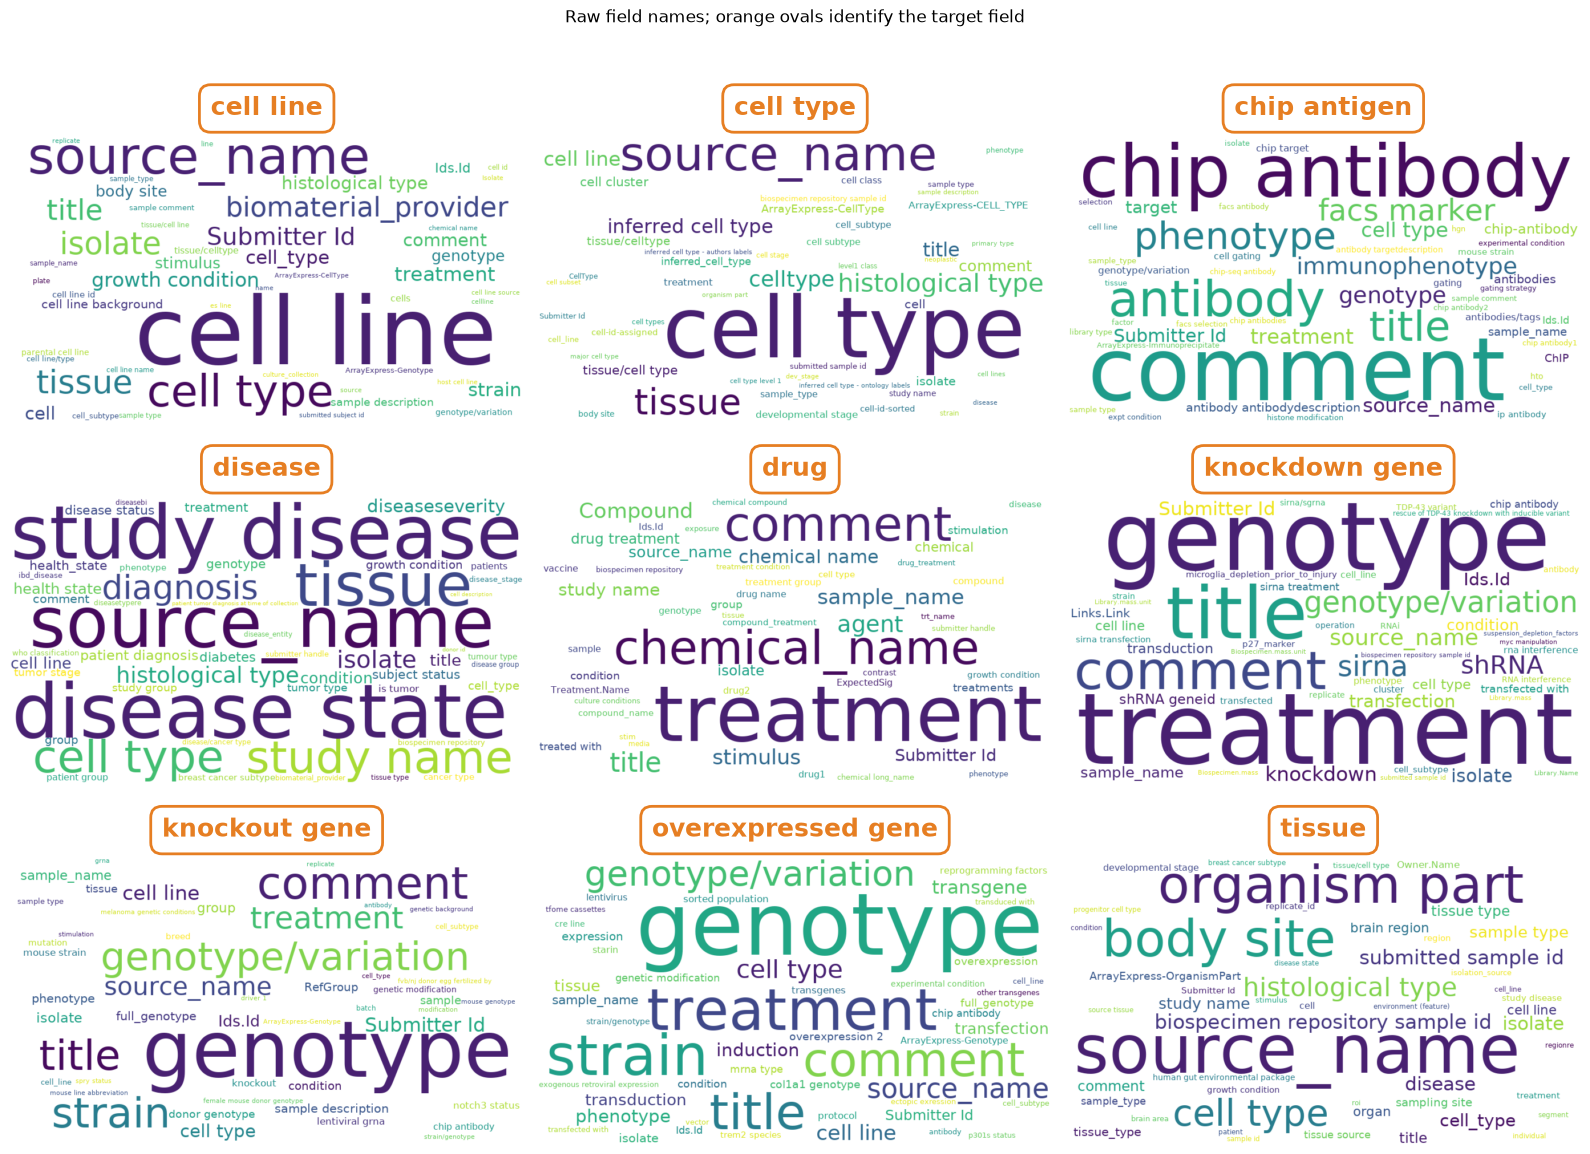

In [12]:
# TAG CLOUDS: RAW FIELD NAMES WITH WRAPPED OVAL TARGET TITLES
import textwrap

from matplotlib.font_manager import findfont
from wordcloud import WordCloud

TAG_CLOUD_FONT = findfont("DejaVu Sans")


def plot_raw_field_tag_clouds(
    exploded: pd.DataFrame,
    max_words: int = 50,
    figsize: tuple[float, float] = (16, 12),
) -> None:
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.ravel()

    for axis, target_field in zip(axes, TARGET_FIELDS):
        counts = exploded.loc[
            (exploded["target_field"] == target_field) & (exploded["raw_field"] != target_field),
            "raw_field",
        ].value_counts().head(max_words)
        cloud = WordCloud(
            width=900,
            height=500,
            max_words=max_words,
            font_path=TAG_CLOUD_FONT,
            background_color="white",
            colormap="viridis",
            collocations=False,
            prefer_horizontal=1.0,
            random_state=42,
        ).generate_from_frequencies(counts.to_dict())
        axis.imshow(cloud, interpolation="bilinear")
        axis.set_title(
            textwrap.fill(target_field.replace("_", " "), width=24),
            fontsize=18,
            fontweight="bold",
            color="#e67e22",
            pad=16,
            bbox={"boxstyle": "round,pad=0.45", "facecolor": "white", "edgecolor": "#e67e22", "linewidth": 2},
        )
        axis.axis("off")

    for axis in axes[len(TARGET_FIELDS) :]:
        axis.axis("off")
    fig.suptitle("Raw field names; orange ovals identify the target field", y=0.995)
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()


plot_raw_field_tag_clouds(exploded)

### How concentrated is that evidence, exactly?

The table above hides how "concentrated" each field's evidence really is, since `other` lumps everything past the top 20 into one number. The two charts below show this from both sides, for the same 9 target fields, side by side. The left chart is about evidence VOLUME: how much of a field's matched evidence the single top raw field covers alone, how much the next 4 add (fields 2-5), the next 15 (fields 6-20), the next 80 (fields 21-100), and finally everything beyond the top 100 -- the segments always sum to 100%. A bar that's almost entirely dark means a handful of names carry the field; a bar with a long light tail means the evidence really is scattered across hundreds of differently-named fields. The right chart is about the field VOCABULARY itself: how many distinct raw field names are needed to reach 90% of a field's evidence, how many more names are used more than once without being needed for that 90%, and how many are singletons -- a raw field name that shows up in evidence for exactly one BioSample record (not one BioProject: the same name can still repeat across many samples within a single BioProject and count as a singleton here, since this counts BioSample-level evidence rows, not distinct projects).

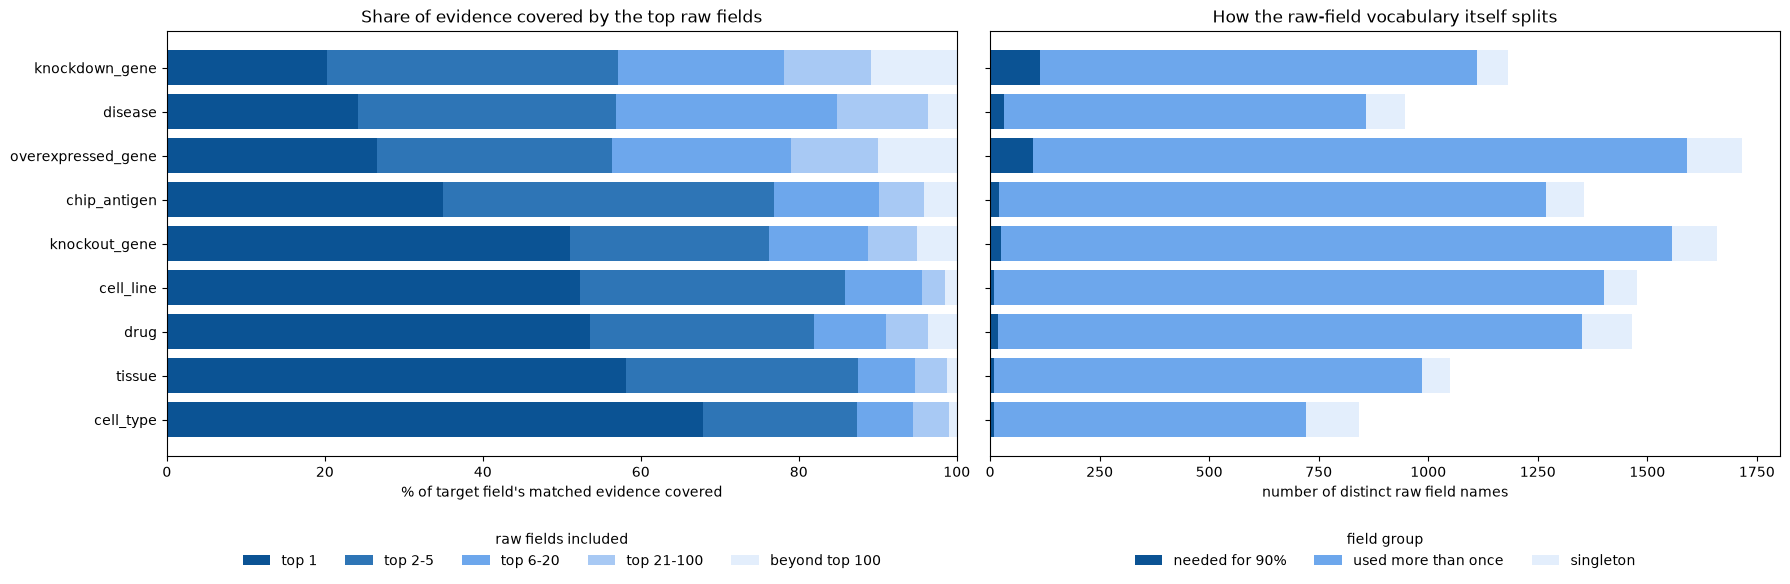

In [13]:
# EVIDENCE CONCENTRATION, TWO VIEWS SIDE BY SIDE: SHARE OF EVIDENCE VS. SIZE OF THE FIELD VOCABULARY
def concentration_by_threshold_segments(
    exploded: pd.DataFrame, thresholds: tuple[int, ...] = (1, 5, 20, 100)
) -> tuple[pd.DataFrame, list[str]]:
    rows = []
    for target_field in TARGET_FIELDS:
        counts = exploded.loc[exploded["target_field"] == target_field, "raw_field"].value_counts()
        curve = concentration_curve(counts)
        cum = {t: curve.loc[curve["n_fields"] == min(t, len(curve)), "pct_covered"].iloc[0] for t in thresholds}
        rows.append({"target_field": target_field, **cum})
    table = pd.DataFrame(rows).set_index("target_field").sort_values(thresholds[0], ascending=False)

    # cumulative coverage per threshold -> incremental segments, so the stacked bar sums to 100%
    segment_labels = [f"top {thresholds[0]}"]
    segment_labels += [f"top {thresholds[i - 1] + 1}-{thresholds[i]}" for i in range(1, len(thresholds))]
    segment_labels += [f"beyond top {thresholds[-1]}"]

    segments = pd.DataFrame(index=table.index)
    segments[segment_labels[0]] = table[thresholds[0]]
    for i in range(1, len(thresholds)):
        segments[segment_labels[i]] = table[thresholds[i]] - table[thresholds[i - 1]]
    segments[segment_labels[-1]] = 100 - table[thresholds[-1]]
    return segments, segment_labels


def field_count_segments(exploded: pd.DataFrame, threshold: float = 90.0) -> tuple[pd.DataFrame, list[str]]:
    """Splits each target field's raw-field VOCABULARY (a count of distinct names, not evidence
    volume) into three non-overlapping groups: the top names needed to reach `threshold`% of
    evidence, the rest of the names used more than once, and singletons (see the markdown above
    for exactly what "singleton" counts).
    """
    rows = []
    for target_field in TARGET_FIELDS:
        counts = exploded.loc[exploded["target_field"] == target_field, "raw_field"].value_counts()
        curve = concentration_curve(counts)
        n_for_threshold = int(curve.loc[curve["pct_covered"] >= threshold, "n_fields"].min())
        n_used_more_than_once = int((counts > 1).sum())
        n_singleton = int((counts == 1).sum())
        n_for_threshold = min(n_for_threshold, n_used_more_than_once)  # guards a fully flat field where even the top names are singletons
        rows.append(
            {
                "target_field": target_field,
                f"needed for {int(threshold)}%": n_for_threshold,
                "used more than once": n_used_more_than_once - n_for_threshold,
                "singleton": n_singleton,
            }
        )
    segments = pd.DataFrame(rows).set_index("target_field")
    return segments, list(segments.columns)


def plot_evidence_concentration(exploded: pd.DataFrame, figsize: tuple[float, float] = (18, 6)) -> None:
    threshold_segments, threshold_labels = concentration_by_threshold_segments(exploded)
    field_segments, field_labels = field_count_segments(exploded)
    order = threshold_segments.index  # both panels share the same target-field order (by top-1 concentration)
    field_segments = field_segments.loc[order]

    threshold_colors = ["#0b5394", "#2e75b6", "#6da7ec", "#a8c9f4", "#e3eefc"][: len(threshold_labels)]
    field_colors = ["#0b5394", "#6da7ec", "#e3eefc"]  # same blue family as the left panel, light = long tail in both

    fig, (ax_pct, ax_count) = plt.subplots(1, 2, figsize=figsize, sharey=True)
    y_pos = range(len(order))
    for ax, segments, labels, colors, xlabel, title, legend_title in [
        (ax_pct, threshold_segments, threshold_labels, threshold_colors, "% of target field's matched evidence covered", "Share of evidence covered by the top raw fields", "raw fields included"),
        (ax_count, field_segments, field_labels, field_colors, "number of distinct raw field names", "How the raw-field vocabulary itself splits", "field group"),
    ]:
        left = pd.Series(0.0, index=segments.index)
        for label, color in zip(labels, colors):
            ax.barh(y_pos, segments[label], left=left, label=label, color=color)
            left += segments[label]
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(order)
        ax.set_xlabel(xlabel)
        ax.set_title(title)
        ax.legend(title=legend_title, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(labels), frameon=False)
    ax_pct.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()


plot_evidence_concentration(exploded)

Fields like `cell_type`/`tissue`/`cell_line` are dominated by a small handful of raw field names -- most of the "8,000+ different fields" problem for these is a long tail that barely matters in volume.
Fields like `disease`/`knockout_gene`/`overexpressed_gene`/`knockdown_gene` need many more distinct raw fields to cover the same share of evidence -- their information really is scattered across a wider variety of submitter-chosen field names, which is exactly the harder case an LLM-based approach is for.

A large share of each target field's raw-field vocabulary is used exactly once, but those singletons account for a negligible share of actual evidence -- confirming that the "8,000+ fields" figure is dominated by rarely-used, idiosyncratic names, and that the LLM's job is really about a much smaller, tractable set of recurring names plus a long noisy tail.

## Where the evidence comes from: the target field itself, another structured field, or free text

Each evidence match is classified by where in the record it was found: in the target field itself, in a different structured attribute, or in a free-text field. This section compares that mix across target fields and shows how it changes over time.

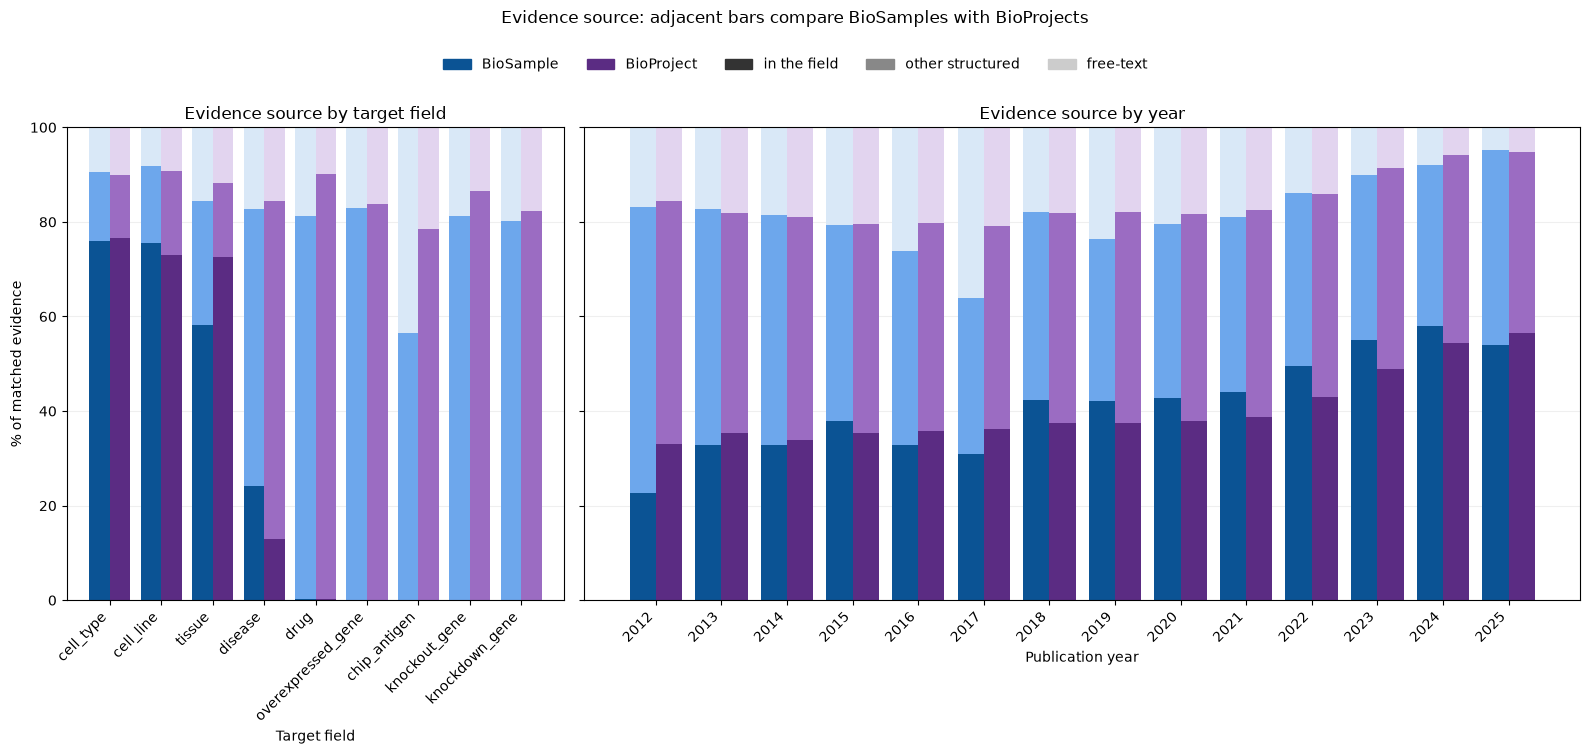

In [14]:
# EVIDENCE SOURCE: ADJACENT BIOSAMPLE/BIOPROJECT BARS, BY FIELD AND YEAR
EVIDENCE_SOURCE_ORDER = ["in the field", "other structured", "free-text"]
LEVEL_COLORS = {
    "BioSample": ["#0b5394", "#6da7ec", "#d9e8f7"],
    "BioProject": ["#5b2c83", "#9b6cc2", "#e2d4ef"],
}
SOURCE_LEGEND_COLORS = ["#333333", "#888888", "#cccccc"]


def classify_evidence_source(exploded: pd.DataFrame) -> pd.Series:
    target_norm = exploded["target_field"].map(normalize_field_name)
    in_field = exploded["raw_field_norm"] == target_norm
    return pd.Series(
        np.select([in_field, exploded["is_free_text"]], ["in the field", "free-text"], default="other structured"),
        index=exploded.index,
    )


exploded["evidence_source"] = classify_evidence_source(exploded)


def evidence_source_percentages(evidence: pd.DataFrame, group_columns: list[str]) -> pd.DataFrame:
    counts = evidence.groupby([*group_columns, "evidence_source"]).size().unstack(fill_value=0)
    counts = counts.reindex(columns=EVIDENCE_SOURCE_ORDER, fill_value=0)
    return 100 * counts.div(counts.sum(axis=1), axis=0)


def evidence_source_over_time(evidence: pd.DataFrame, date_col: str = "year_publication") -> pd.DataFrame:
    subset = evidence.dropna(subset=[date_col])
    subset = subset[subset[date_col].between(*YEAR_RANGE)]
    counts = subset.groupby([date_col, "evidence_source"]).size().unstack(fill_value=0)
    return (100 * counts.div(counts.sum(axis=1), axis=0)).reindex(columns=EVIDENCE_SOURCE_ORDER, fill_value=0)


def plot_evidence_source_levels(exploded: pd.DataFrame, figsize: tuple[float, float] = (16, 7)) -> None:
    bioproject_field = exploded.dropna(subset=["bioproject_id"]).drop_duplicates(
        ["bioproject_id", "target_field", "raw_field", "evidence_source"]
    )
    bioproject_year = exploded.dropna(subset=["bioproject_id", "year_publication"]).drop_duplicates(
        ["bioproject_id", "year_publication", "target_field", "raw_field", "evidence_source"]
    )
    field_data = [("BioSample", exploded), ("BioProject", bioproject_field)]
    year_data = [("BioSample", exploded), ("BioProject", bioproject_year)]

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, gridspec_kw={"width_ratios": [1, 2]})
    for ax, data, group_column, xlabel, title in [
        (axes[0], field_data, "target_field", "Target field", "Evidence source by target field"),
        (axes[1], year_data, "year_publication", "Publication year", "Evidence source by year"),
    ]:
        percentages_by_level = []
        for level_label, evidence in data:
            if group_column == "year_publication":
                percentages_by_level.append((level_label, evidence_source_over_time(evidence)))
            else:
                percentages_by_level.append((level_label, evidence_source_percentages(evidence, [group_column])))
        if group_column == "target_field":
            biosample_percentages = percentages_by_level[0][1]
            categories = sorted(
                biosample_percentages.index,
                key=lambda category: (
                    biosample_percentages.loc[category, "in the field"],
                    biosample_percentages.loc[category, "other structured"],
                ),
                reverse=True,
            )
        else:
            categories = sorted(set().union(*(percentages.index for _, percentages in percentages_by_level)))
        for category_index, category in enumerate(categories):
            group_start = category_index * 2.5
            for bar_position, (level_label, percentages) in zip([group_start, group_start + 1], percentages_by_level):
                row = percentages.reindex([category]).fillna(0)
                bottom = 0.0
                for source, color in zip(EVIDENCE_SOURCE_ORDER, LEVEL_COLORS[level_label]):
                    value = row[source].iloc[0]
                    ax.bar(bar_position, value, bottom=bottom, width=1.0, color=color)
                    bottom += value

        ax.set_xticks([index * 2.5 + 0.5 for index in range(len(categories))], categories, rotation=45, ha="right")
        ax.set_xlabel(xlabel)
        ax.set_ylim(0, 100)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("% of matched evidence")
    level_handles = [
        plt.Rectangle((0, 0), 1, 1, color=LEVEL_COLORS[level][0], label=level)
        for level in ["BioSample", "BioProject"]
    ]
    source_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color, label=source)
        for source, color in zip(EVIDENCE_SOURCE_ORDER, SOURCE_LEGEND_COLORS)
    ]
    fig.legend(handles=level_handles + source_handles, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle("Evidence source: adjacent bars compare BioSamples with BioProjects", y=1.07)
    plt.tight_layout()
    plt.show()


plot_evidence_source_levels(exploded)

The free-text share is not a simple decline: it RISES from 2012 to a peak around 2017, then falls steadily and substantially through 2025 -- growing "in the field" and "other structured" share correspondingly.

The post-2017 decline (the larger, more sustained part of the pattern) lines up plausibly -- not provably from this data alone -- with the broader push toward structured, checklist-driven metadata submission over the last decade: NCBI/DDBJ's harmonized-attribute BioSample packages, MIxS/MIAME-style minimum-information checklists, and journal/funder data-sharing mandates requiring structured sample metadata have all become more consistently enforced industry-wide since roughly the late 2010s.

The pre-2017 rise doesn't fit that story as neatly, and could instead reflect which submitters/BioProjects happened to dominate the crate's earlier years rather than a field-wide behavior change -- confirming either direction would need comparing against actual standards-rollout dates and per-submitter breakdowns, which is out of scope here.

The pooled year-trend charts further below (rarefied unique raw-field count) show a similar late-decline shape -- diversity rising to a peak around 2020-2021 then falling through 2025 -- consistent with the same recent-years story.

## Why isn't every record linked to a BioProject?

BioProject linkage matters because the same raw field can dominate very differently depending on whether you count by BioSample (a BioProject with many samples counts many times) or by BioProject (each contributes once per field it uses, however many samples it has) -- but that link isn't in the raw crate for every record. This isn't a gap in this pipeline's parsing -- inspecting the raw JSON directly confirms the link is genuinely absent from the record itself, for three distinct reasons tied to *where* the record originally came from (its accession prefix):
- **EBI/ENA-origin records** (`SAMEA`, often imported via ArrayExpress) use ENA's own "Study" concept instead of NCBI's BioProject system, and carry no `Links.Link` entry with `target: "bioproject"` in this schema at all -- there is nothing to find here, in this record or any API built on this same schema.
- **Old NCBI records** (`SAMN`, mostly pre-2011/2012) predate NCBI's BioProject umbrella becoming mandatory -- their `Attributes` block is often simply `null`, with no `Links` section either.
- **Some DDBJ records** (`SAMD`) were submitted with only a bare SRA/DRA run link and no explicit BioProject attribute or link.

The origin-archive split below explains the gap far better than a per-category breakdown does.

In [15]:
# BIOPROJECT LINKAGE COVERAGE, BY CATEGORY AND ORIGIN ARCHIVE -- AS TEXT, NOT TABLES
coverage_by_category = 100 * exploded.groupby("category")["bioproject_id"].apply(lambda s: s.notna().mean())
md(
    "**BioProject linkage coverage** (share of matched-evidence rows with a resolvable primary BioProject), by category: "
    + ", ".join(f"**{pct:.1f}%** {category}" for category, pct in coverage_by_category.sort_values(ascending=False).items())
    + ". ChIP-Atlas records link to a BioProject far less often than DDBJ RNA-Seq ones, so ChIP-Atlas-heavy target fields' BioProject-level stats below rest on a smaller, less representative subset."
)

ORIGIN_ARCHIVE_BY_PREFIX = {"SAMN": "NCBI (SAMN)", "SAMD": "DDBJ (SAMD)", "SAME": "EBI/ENA (SAMEA)"}
exploded["origin_archive"] = exploded["accession"].str[:4].map(ORIGIN_ARCHIVE_BY_PREFIX)
coverage_by_origin = 100 * exploded.groupby("origin_archive")["bioproject_id"].apply(lambda s: s.notna().mean())

by_accession = exploded.drop_duplicates("accession")[["accession", "bioproject_id", "origin_archive"]]
missing = by_accession[by_accession["bioproject_id"].isna()]
missing_by_origin = missing["origin_archive"].value_counts()

md(
    "...and by origin archive (accession prefix), the real driver of the gap: "
    + ", ".join(f"**{pct:.1f}%** {origin}" for origin, pct in coverage_by_origin.sort_values(ascending=False).items())
    + f". Across the **{len(by_accession):,}** distinct BioSamples with at least one traced-back evidence value, **{len(missing):,}** "
    f"({100 * len(missing) / len(by_accession):.1f}%) have no resolvable BioProject: "
    f"**{missing_by_origin.get('EBI/ENA (SAMEA)', 0):,}** are EBI/ENA-origin (100% of that origin, by construction -- see above), "
    f"**{missing_by_origin.get('NCBI (SAMN)', 0):,}** are NCBI records (mostly pre-BioProject-era), "
    f"and **{missing_by_origin.get('DDBJ (SAMD)', 0):,}** are DDBJ records submitted without one."
)

**BioProject linkage coverage** (share of matched-evidence rows with a resolvable primary BioProject), by category: **90.0%** ChIP-Atlas, **78.4%** DDBJ RNA-Seq. ChIP-Atlas records link to a BioProject far less often than DDBJ RNA-Seq ones, so ChIP-Atlas-heavy target fields' BioProject-level stats below rest on a smaller, less representative subset.

...and by origin archive (accession prefix), the real driver of the gap: **91.8%** NCBI (SAMN), **52.9%** DDBJ (SAMD), **0.0%** EBI/ENA (SAMEA). Across the **3,946,838** distinct BioSamples with at least one traced-back evidence value, **638,334** (16.2%) have no resolvable BioProject: **323,746** are EBI/ENA-origin (100% of that origin, by construction -- see above), **294,263** are NCBI records (mostly pre-BioProject-era), and **20,325** are DDBJ records submitted without one.

**Could the missing ones be backfilled through an API?** Partially, and not cheaply. For NCBI (`SAMN`) and DDBJ (`SAMD`) records, NCBI's E-utilities and DDBJ's own REST API can look up an accession's linked BioProject -- and both support batched lookups (NCBI's `efetch`/`esummary` accept up to ~200 accessions per request), so the real bottleneck is API rate limits, not the number of records: hundreds of thousands of missing `SAMN`/`SAMD` accessions would mean thousands of batched requests, likely hours of wall-clock time at NCBI's default (unauthenticated) rate limit. Even then, a real fraction of the missing `SAMN` records are simply from before BioProject existed as a concept -- there is no BioProject to find for them, at any API. For EBI/ENA (`SAMEA`) records, this would need an entirely different API and a different target concept (ENA's "Study" accession, not a BioProject) -- a separate piece of work, not an extension of the same lookup. So a full backfill is a multi-archive engineering effort with a lower ceiling than 100%, not a one-line API call.

## How does raw-field-name diversity vary by year?

Two different, genuinely different dates are available per BioSample: `submission_date` (when the record was first submitted, not always present) and `publication_date` (when it became public, always present). Checked directly below: how often each is missing, and -- for records with both -- how much they actually differ, to decide whether using one instead of the other would materially change a year-based analysis.

In [16]:
# MISSING RATES FOR EACH DATE FIELD
md(
    f"`submission_date` missing for **{100 * metadata['submission_date'].isna().mean():.2f}%** of accessions; "
    f"`publication_date` missing for **{100 * metadata['publication_date'].isna().mean():.2f}%**."
)

`submission_date` missing for **1.02%** of accessions; `publication_date` missing for **0.00%**.

In [17]:
# HOW MUCH DO submission_date AND publication_date DISAGREE, WHERE BOTH EXIST
both_dates = metadata.dropna(subset=["submission_date", "publication_date"]).copy()
both_dates["submission_dt"] = pd.to_datetime(both_dates["submission_date"], format="mixed", utc=True, errors="coerce")
both_dates["publication_dt"] = pd.to_datetime(both_dates["publication_date"], format="mixed", utc=True, errors="coerce")
both_dates = both_dates.dropna(subset=["submission_dt", "publication_dt"])
diff_days = (both_dates["publication_dt"] - both_dates["submission_dt"]).dt.total_seconds() / 86400
n_negative = (diff_days < 0).sum()

md(
    f"Among **{len(both_dates):,}** accessions with both dates, the gap between them (`publication_date - submission_date`): "
    f"median **{diff_days.median():.0f} days**, mean **{diff_days.mean():.0f} days**, "
    f"min **{diff_days.min():,.0f} days**, max **{diff_days.max():,.0f} days**. "
    f"The mean sitting more than double the median, and **{n_negative:,}** records ({100 * n_negative / len(both_dates):.1f}%) showing a NEGATIVE gap -- published before their recorded submission date, up to {abs(diff_days.min()) / 365.25:.0f} years earlier at the extreme -- "
    "suggests `submission_date` isn't always the record's true original submission: for records re-registered or imported into this system later, it likely reflects that later event, while `publication_date` keeps the original archive-of-origin's first-public date. "
    f"Only **{100 * (both_dates['submission_dt'].dt.year == both_dates['publication_dt'].dt.year).mean():.1f}%** "
    f"share the same calendar year, and **{100 * (diff_days.abs() <= 90).mean():.1f}%** are within 90 days. "
    "The two dates diverge enough, for a large enough share of records, that a year-based trend could plausibly look different depending on which is used -- so both are shown separately below, not collapsed into one."
)

Among **4,144,993** accessions with both dates, the gap between them (`publication_date - submission_date`): median **96 days**, mean **220 days**, min **-4,448 days**, max **5,671 days**. The mean sitting more than double the median, and **627,894** records (15.1%) showing a NEGATIVE gap -- published before their recorded submission date, up to 12 years earlier at the extreme -- suggests `submission_date` isn't always the record's true original submission: for records re-registered or imported into this system later, it likely reflects that later event, while `publication_date` keeps the original archive-of-origin's first-public date. Only **59.1%** share the same calendar year, and **48.8%** are within 90 days. The two dates diverge enough, for a large enough share of records, that a year-based trend could plausibly look different depending on which is used -- so both are shown separately below, not collapsed into one.

**Controlling for how many biosamples/BioProjects exist per year.** A year with more biosamples mechanically has more unique raw field names, even with no real change in naming behavior. Every year-trend chart below uses **rarefaction** (from ecological species-richness estimation): each year is repeatedly subsampled down to the same number of units (biosamples, or BioProjects for the BioProject-level charts -- whichever is the smaller across years) before counting unique raw field names, averaged over resamples, so the comparison isn't just tracking how much data exists for that year.

One combined figure below, 4 rows (biosample x submission_date, biosample x publication_date, BioProject x submission_date, BioProject x publication_date) x 2 columns: left is a trend line per target field (do individual fields move differently over time?), right is a pooled bar chart contrasting raw vs. regex-normalized counts (does normalization close more of the gap in some years than others?).

Restricted to 2012-2025: earlier years have too few records for a stable rarefied estimate, and 2026 is only partially elapsed as of this notebook's run.

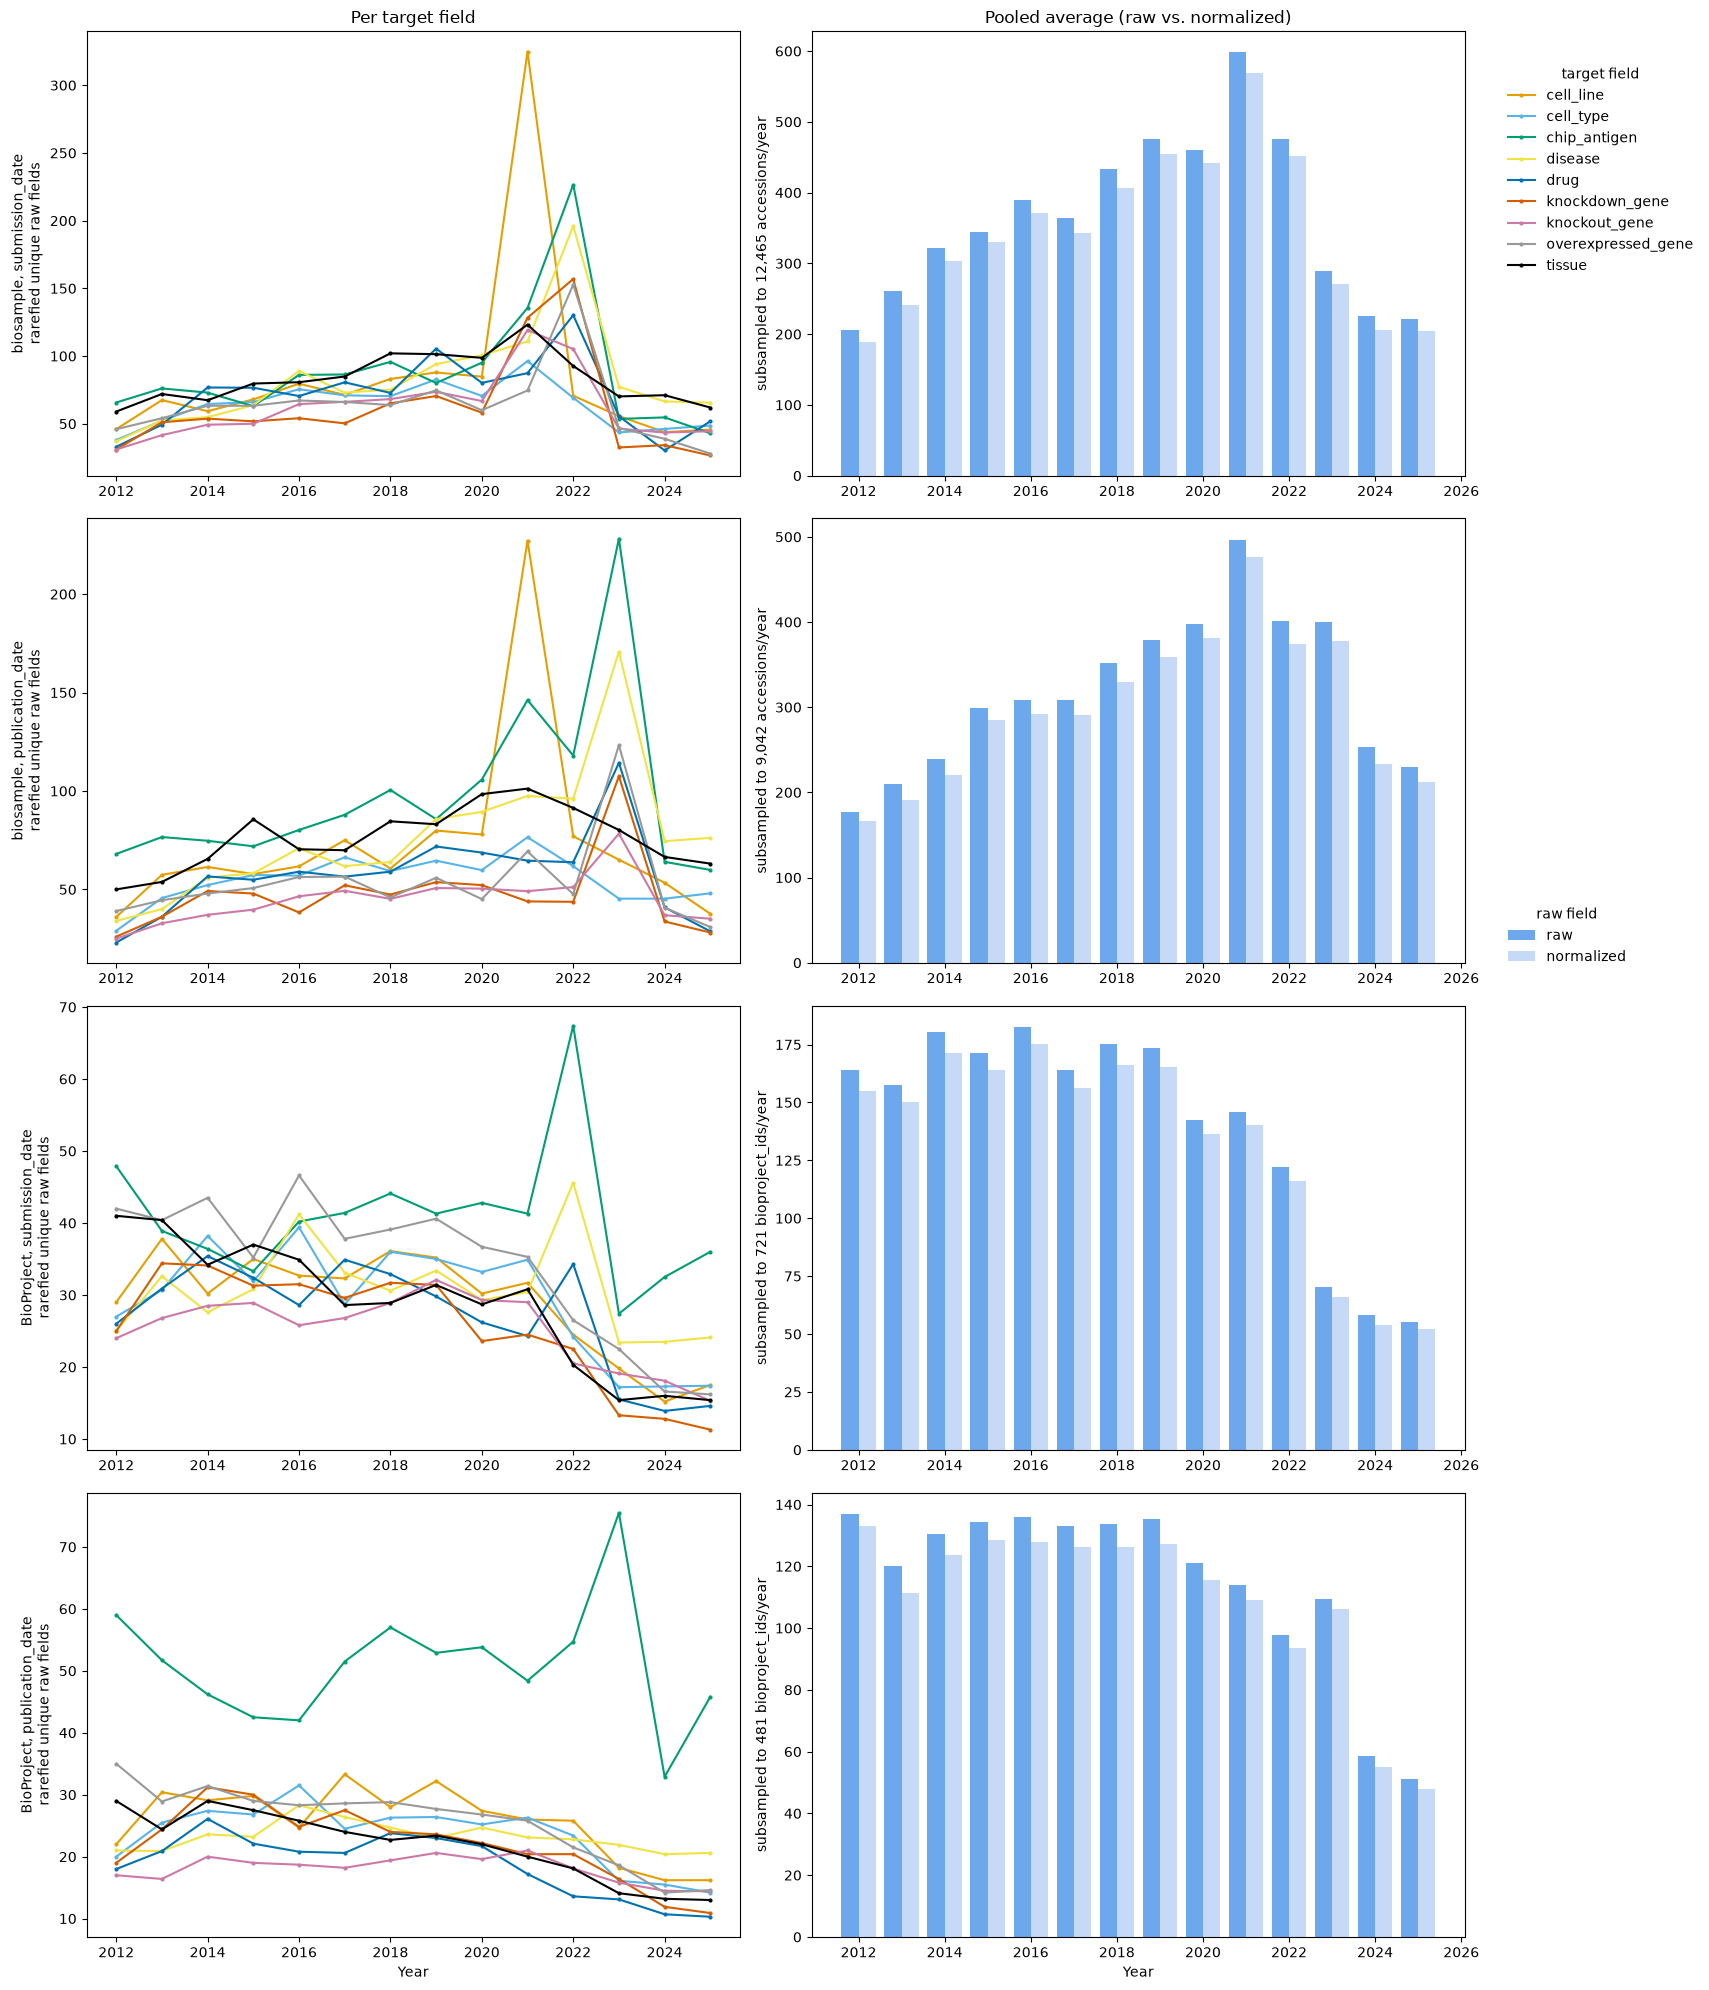

In [18]:
# RAREFIED UNIQUE RAW-FIELD COUNT PER YEAR: ALL 4 LEVEL x DATE COMBOS IN ONE 4-ROW x 2-COLUMN FIGURE
YEAR_DIVERSITY_COMBOS = [
    ("year_submission", "accession", "biosample", "submission_date"),
    ("year_publication", "accession", "biosample", "publication_date"),
    ("year_submission", "bioproject_id", "BioProject", "submission_date"),
    ("year_publication", "bioproject_id", "BioProject", "publication_date"),
]


def plot_year_diversity_grid(exploded: pd.DataFrame, figsize: tuple[float, float] = (15, 20)) -> None:
    fig, axes = plt.subplots(len(YEAR_DIVERSITY_COMBOS), 2, figsize=figsize)

    for row, (date_col, unit_col, level_label, date_label) in enumerate(YEAR_DIVERSITY_COMBOS):
        ax_trend, ax_avg = axes[row]

        # slim to just the columns this combo needs before any filtering -- filtering the full
        # ~20-column exploded frame repeatedly (9 fields + 1 pooled, per combo) was the actual
        # bottleneck, copying columns (raw_texts, assigned_term_synonyms, ...) never used here
        combo_cols = ["target_field", date_col, unit_col, "raw_field", "raw_field_norm"]
        combo_base = exploded[combo_cols].dropna(subset=[date_col, unit_col])
        combo_base = combo_base[combo_base[date_col].between(*YEAR_RANGE)]

        # left: trend line per target field
        for target_field in TARGET_FIELDS:
            sub = combo_base[combo_base["target_field"] == target_field]
            res = rarefied_unique_counts(sub, date_col, unit_col, "raw_field", n_iter=N_RAREFACTION_ITER)
            ax_trend.plot(res[date_col], res["mean_unique"], label=target_field, color=TARGET_FIELD_COLORS[target_field], linewidth=1.5, marker="o", markersize=2)
        ax_trend.set_ylabel(f"{level_label}, {date_label}\nrarefied unique raw fields")

        # right: pooled average, raw vs. normalized
        raw_res = rarefied_unique_counts(combo_base, date_col, unit_col, "raw_field", n_iter=N_RAREFACTION_ITER)
        norm_res = rarefied_unique_counts(combo_base, date_col, unit_col, "raw_field_norm", n_iter=N_RAREFACTION_ITER)
        width = 0.4
        years = raw_res[date_col]
        ax_avg.bar(years - width / 2, raw_res["mean_unique"], width=width, label="raw", color="#6da7ec")
        ax_avg.bar(years + width / 2, norm_res["mean_unique"], width=width, label="normalized", color="#c6daf8")
        ax_avg.set_ylabel(f"subsampled to {int(raw_res['k'].iloc[0]):,} {unit_col}s/year")

        if row == 0:
            ax_trend.set_title("Per target field")
            ax_avg.set_title("Pooled average (raw vs. normalized)")
        if row == len(YEAR_DIVERSITY_COMBOS) - 1:
            ax_trend.set_xlabel("Year")
            ax_avg.set_xlabel("Year")

    field_handles, field_labels = axes[0, 0].get_legend_handles_labels()
    avg_handles, avg_labels = axes[0, 1].get_legend_handles_labels()
    fig.legend(field_handles, field_labels, title="target field", loc="upper left", bbox_to_anchor=(1.0, 0.97), frameon=False)
    fig.legend(avg_handles, avg_labels, title="raw field", loc="upper left", bbox_to_anchor=(1.0, 0.55), frameon=False)
    plt.tight_layout()
    plt.show()


plot_year_diversity_grid(exploded)

### What does the raw (non-rarefied) growth curve look like?

Rarefaction above deliberately removes the effect of "more data this year"; this section restores it, to see the field vocabulary's actual, uncorrected growth. Restricted to BioSample x `publication_date` (always present, unlike `submission_date` -- see above) to keep this to one representative view rather than repeating all 4 level x date combos. Two groups of two: the top row is each year's own count (per target field, then averaged across fields); the bottom row is the cumulative, ever-seen-by-that-year count, to check whether the vocabulary plateaus or keeps growing.

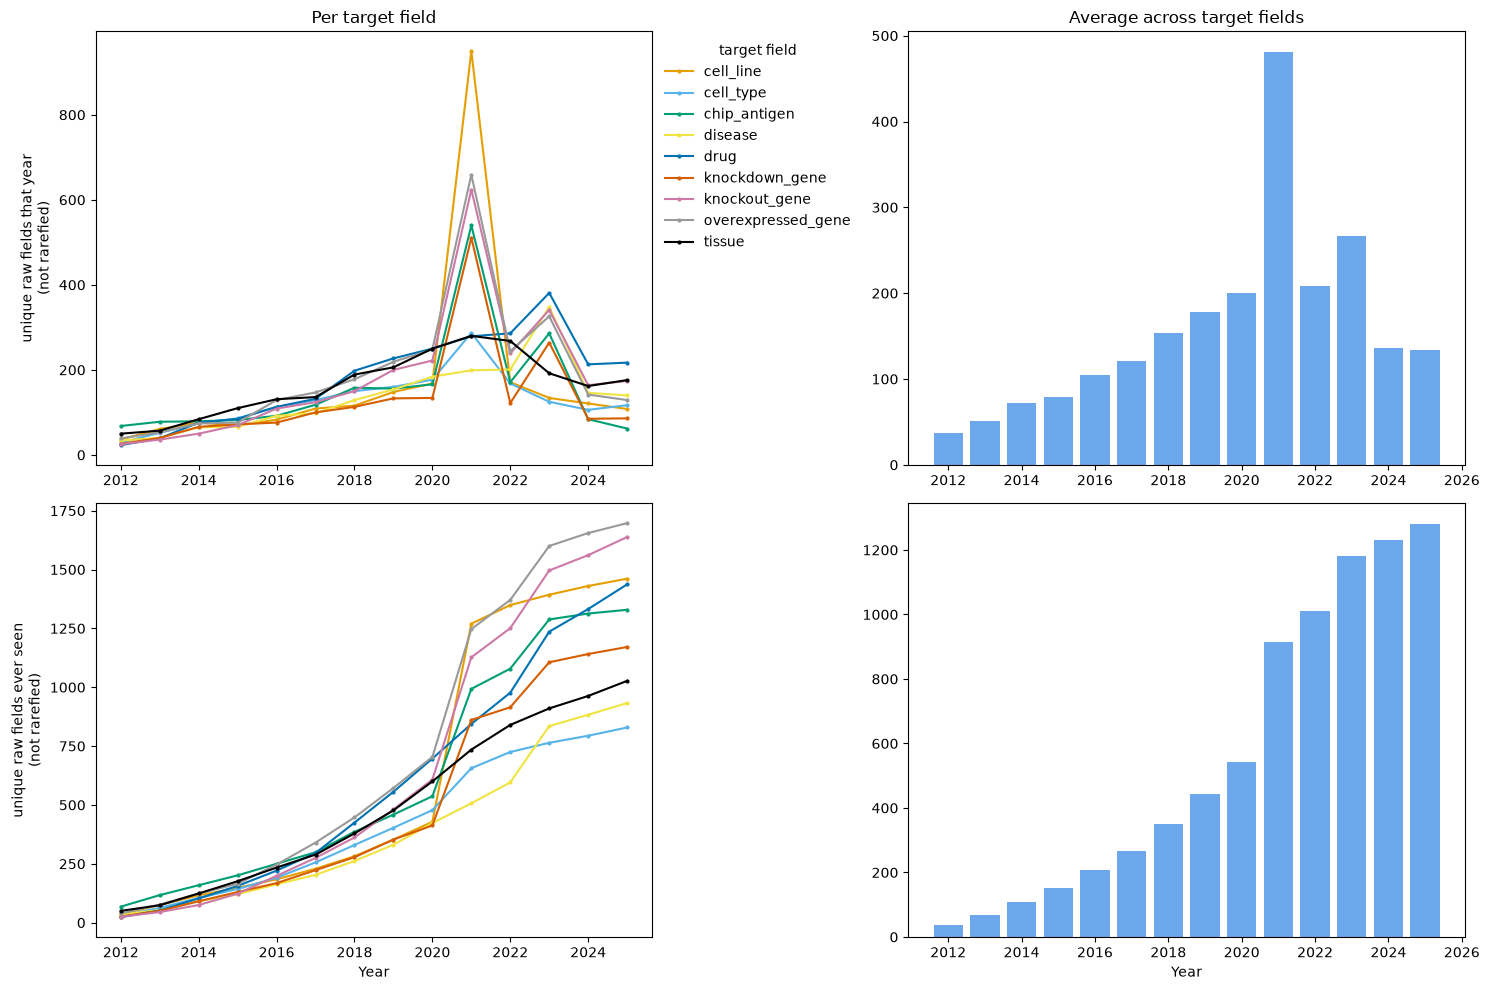

In [19]:
# NON-RAREFIED YEARLY AND CUMULATIVE UNIQUE-RAW-FIELD COUNTS, BIOSAMPLE x publication_date
def yearly_unique_field_counts(exploded: pd.DataFrame, date_col: str) -> pd.DataFrame:
    subset = exploded.dropna(subset=[date_col])
    subset = subset[subset[date_col].between(*YEAR_RANGE)]
    return subset.groupby(["target_field", date_col])["raw_field"].nunique().rename("n_unique").reset_index()


def cumulative_unique_field_counts(exploded: pd.DataFrame, date_col: str, years: list[int]) -> pd.DataFrame:
    """Running union of raw field names seen in each target field up to and including each year
    (not just that year's own count), to check whether the vocabulary plateaus over time.
    """
    rows = []
    for target_field in TARGET_FIELDS:
        sub = exploded[(exploded["target_field"] == target_field) & exploded[date_col].between(*YEAR_RANGE)]
        seen: set[str] = set()
        for year in years:
            seen |= set(sub.loc[sub[date_col] == year, "raw_field"])
            rows.append({"target_field": target_field, date_col: year, "n_unique_cumulative": len(seen)})
    return pd.DataFrame(rows)


def plot_year_growth_grid(exploded: pd.DataFrame, date_col: str = "year_publication", figsize: tuple[float, float] = (15, 10)) -> None:
    yearly = yearly_unique_field_counts(exploded, date_col)
    years = sorted(yearly[date_col].unique())
    cumulative = cumulative_unique_field_counts(exploded, date_col, years)

    fig, ((ax_yearly_field, ax_yearly_avg), (ax_cum_field, ax_cum_avg)) = plt.subplots(2, 2, figsize=figsize)

    for target_field in TARGET_FIELDS:
        field_yearly = yearly[yearly["target_field"] == target_field]
        ax_yearly_field.plot(field_yearly[date_col], field_yearly["n_unique"], label=target_field, color=TARGET_FIELD_COLORS[target_field], linewidth=1.5, marker="o", markersize=2)
        field_cum = cumulative[cumulative["target_field"] == target_field]
        ax_cum_field.plot(field_cum[date_col], field_cum["n_unique_cumulative"], label=target_field, color=TARGET_FIELD_COLORS[target_field], linewidth=1.5, marker="o", markersize=2)

    yearly_avg = yearly.groupby(date_col)["n_unique"].mean()
    ax_yearly_avg.bar(yearly_avg.index, yearly_avg.to_numpy(), color="#6da7ec")
    cum_avg = cumulative.groupby(date_col)["n_unique_cumulative"].mean()
    ax_cum_avg.bar(cum_avg.index, cum_avg.to_numpy(), color="#6da7ec")

    ax_yearly_field.set_title("Per target field")
    ax_yearly_avg.set_title("Average across target fields")
    ax_yearly_field.set_ylabel("unique raw fields that year\n(not rarefied)")
    ax_cum_field.set_ylabel("unique raw fields ever seen\n(not rarefied)")
    ax_cum_field.set_xlabel("Year")
    ax_cum_avg.set_xlabel("Year")
    ax_yearly_field.legend(title="target field", loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False)
    plt.tight_layout()
    plt.show()


plot_year_growth_grid(exploded)

## Summary

- The stacked-bar recap (deterministic tiers plus the two Qwen LLM passes, one tier explained per bullet just above it) shows the trace-back check resolves the large majority of extracted values across all 9 target fields, mostly via the strongest deterministic tiers.
- A modest handful of raw field names account for most evidence for `cell_type`/`tissue`/`cell_line`; `disease`/the gene-perturbation fields need many more distinct raw fields to reach the same coverage.
- Regex normalization (case/separator collapsing) reduces the raw field-name count by a real but modest amount -- most of the diversity is genuinely different names, not spelling variants.
- Most of that diversity is a long tail of singleton, one-off field names contributing negligible evidence, and it's spread across many independent submitting labs rather than concentrated in a few.
- Missing BioProject linkage (~16% of BioSamples) is explained almost entirely by *where* a record originated (EBI/ENA-origin records structurally have none; old NCBI records predate BioProject; some DDBJ records were submitted without one) -- not a gap in this pipeline, and only partially, expensively fixable via API.
- Year-over-year naming diversity -- both rarefaction-controlled and the raw, uncontrolled growth curve -- and the evidence-source mix (in-the-field / other-structured / free-text) both show real movement over the crate's history, worth revisiting once the trace-back job reaches 100%.